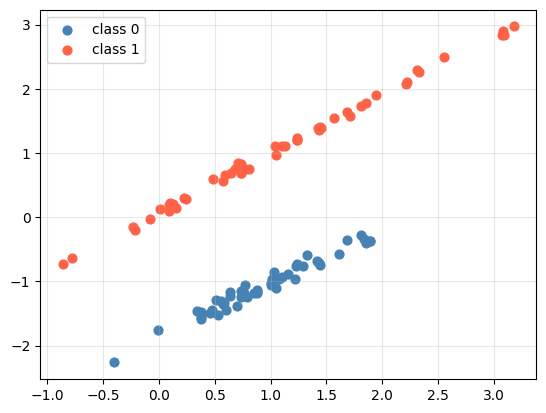

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

np.random.seed(42)

X,Y=make_classification(n_samples=100,n_features=2,n_redundant=0,n_informative=2,n_clusters_per_class=1,random_state=42)

plt.scatter(X[Y==0][:,0],X[Y==0][:,1],color='steelblue',s=40,label='class 0')
plt.scatter(X[Y==1][:,0],X[Y==1][:,1],color='tomato',s=40,label='class 1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


converged at iter 1
learned theta:  [ 0.2   -0.12   0.326]


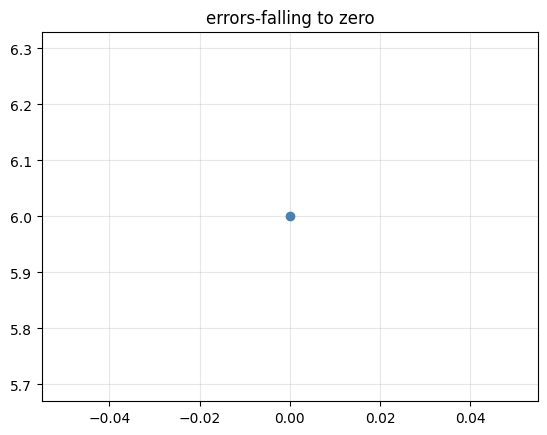

In [16]:
def perceptron(X,Y,learning_rate=0.1,n_iterations=1000):
    m,n=X.shape
    X_b=np.c_[np.ones(m),X]
    theta=np.zeros(n+1)
    errors_per_iteraton=[]
    for iter in range(n_iterations):
        errors=0
        for i in range (m):
            z=np.dot(theta,X_b[i])
            if(z<0):
                y_pred=0
            else:
                y_pred=1
            error=Y[i]-y_pred
            if(error!=0):
                errors+=1
                theta+=learning_rate*(error*X_b[i])
        if(errors==0):
            print("converged at iter",iter)
            break
        errors_per_iteraton.append(errors)
    return theta,errors_per_iteraton

theta_p,errors_per_iteration=perceptron(X,Y)
print("learned theta: ",theta_p.round(3))

plt.plot(errors_per_iteration,color='steelblue',marker='o')
plt.title("errors-falling to zero")
plt.grid(alpha=0.3)
plt.show()

    


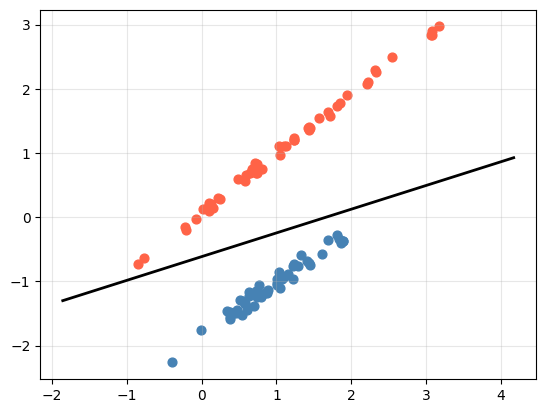

In [17]:
def plot_boundary_perceptron(X,Y,theta):
    x1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300)
    x2=-(theta[0]+theta[1]*x1)/theta[2]
    plt.scatter(X[Y==0][:,0],X[Y==0][:,1],color='steelblue',s=40)
    plt.scatter(X[Y==1][:,0],X[Y==1][:,1],color='tomato',s=40)
    plt.plot(x1,x2,color='black',lw=2)
    plt.grid(alpha=0.3)
plot_boundary_perceptron(X,Y,theta_p)
plt.show()

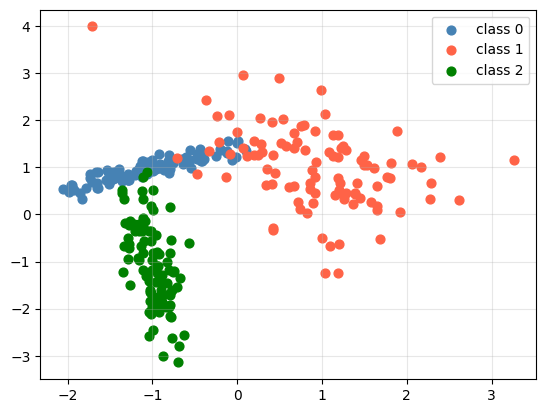

In [18]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

np.random.seed(42)

X,Y=make_classification(n_samples=300,n_features=2,n_classes=3,n_clusters_per_class=1,n_redundant=0,random_state=42,n_informative=2)

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
colors=['steelblue','tomato','green']
for c in range(3):
    plt.scatter(X[Y==c][:,0],X[Y==c][:,1],color=colors[c],s=40,label=f'class {c}')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

softmax output 
 [[0.629 0.231 0.14 ]
 [0.049 0.896 0.054]]
row sums: [1. 1.]


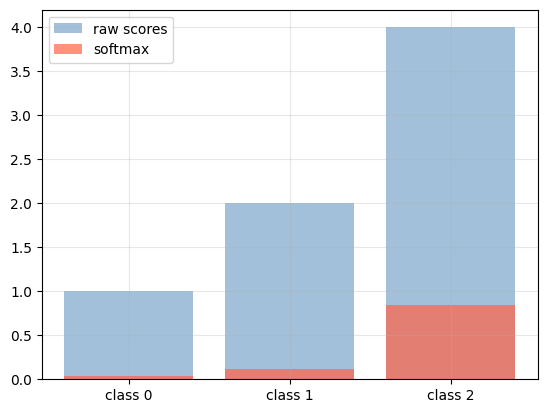

In [19]:
def softmax(z):
    z_stable=z-np.max(z,axis=1,keepdims=True)
    exp_z=np.exp(z_stable)
    return((exp_z)/np.sum(exp_z,axis=1,keepdims=True))

z_test=np.array([[2.0,1.0,0.5],[0.1,3.0,0.2]])
probs=softmax(z_test)
print("softmax output \n", probs.round(3))
print("row sums:",probs.sum(axis=1))

scores = np.array([1.0, 2.0, 4.0])
probs_single = softmax(scores.reshape(1,-1))[0]

plt.bar(["class 0","class 1","class 2"],scores,color='steelblue',label='raw scores',alpha=0.5)
plt.bar(["class 0","class 1","class 2"],probs_single,color='tomato',label='softmax',alpha=.7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

    

In [22]:
#cross entropy needs labels in one-hot format
#class 0 [1,0,0]
#class 1[0,1,0]
#class 2[0,0,1]

def one_hot(y,k):
    m=len(y)
    Y=np.zeros((m,k))
    Y[np.arange(m),y]=1
    return Y
k=3
y_train=one_hot(Y_train,k)
y_test=one_hot(Y_test,k)


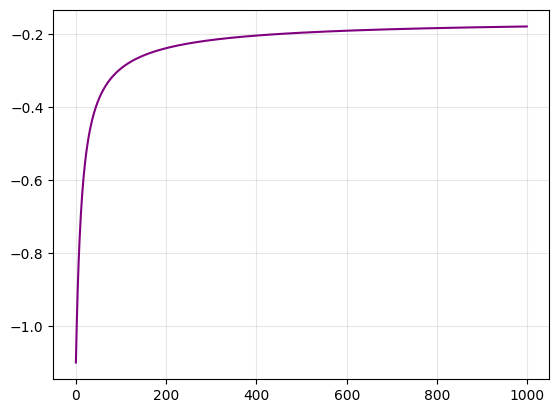

In [33]:
def softmax_regression(X,Y,learning_rate=0.1,n_iterations=1000):
    m,n=X.shape
    k=Y.shape[1]
    X_b = np.c_[np.ones((m, 1)), X]
    theta=np.zeros((n+1,k))
    
    cosf_history=[]
    for i in range(n_iterations):
        z=X_b@theta
        probs=softmax(z)

        cosf=1/m*np.sum(Y*np.log(probs+1e-8))
        cosf_history.append(cosf)
        error=probs-Y
        gradient=1/m*X_b.T@error
        theta-=learning_rate*gradient

    return theta,cosf_history

theta_sm,cosf_sm=softmax_regression(X_train,y_train)

plt.plot(cosf_sm,color='purple')
plt.grid(alpha=0.3)
plt.show()



In [41]:
def predic_softmax(X,theta):
    X_b=np.c_[np.ones((len(X),1)),X]
    probs=softmax(X_b@theta)
    return np.argmax(probs,axis=1)
y_pred=predic_softmax(X_test,theta_sm)

from sklearn.linear_model import LogisticRegression
sk = LogisticRegression( max_iter=1000)
sk.fit(X_train,Y_train)
y_pred_sk=sk.predict(X_test)

print("Scratch softmax accuracy:", accuracy_score(Y_test, y_pred))
print("Sklearn accuracy:        ", accuracy_score(Y_test, y_pred_sk))



Scratch softmax accuracy: 0.8833333333333333
Sklearn accuracy:         0.8833333333333333
